In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Research Question 6: Which Local Authorities consistently outperform or underperform their predicted Attainment 8 score, and is there a geographic pattern among these outliers?

This research question attempts to investigate which Local Authorities over and underperform a predicted Attainment 8 score, based on a linear regression model.

For the purposes of this analysis, the linear regression model will be based on the imd_score, and not the sub-domains, as these all contribute to the overall imd_score, and are likely to introduce substantial multicolinearity. 

LA's are classified as over-performing if their residual (the difference between the actual and predicted attainment8_score) is positive, while they are classified as under-performing if their residual is negative. 

Note that a linear regression model has several assumptions: linearity, normality of residuals, homoscedasticity, and whether residuals are randomly distributed around zero with no clear pattern.



In [49]:
# Importing cleaned dataset
total_dataset = pd.read_csv("/Users/aislinglangston/Desktop/CFG_group_project/data/final_df_total.csv", low_memory=False)

total_dataset.columns

Index(['time_period', 'new_la_code', 'la_name', 'pupil_count',
       'attainment8_average', 'ebacc_aps_average', 'attainment8eng_average',
       'attainment8mat_average', 'attainment8ebacc_average',
       'ebacceng_aps_average', 'ebaccmat_aps_average', 'ebaccsci_aps_average',
       'ebacchum_aps_average', 'ebacclan_aps_average', 'end_year',
       'merge_la_code', 'UTLA19CD', 'UTLA19NM', 'pct_highly_deprived',
       'imd_score', 'income_score', 'employment_score', 'education_score',
       'health_score', 'crime_score', 'barriers_score', 'living_env_score',
       'idaci_score', 'children_subdomain', 'total_population'],
      dtype='object')

It is widely acknowledged that grade inflation occured during the years of teacher assessed grades (TAG) during the Covid-19 pandemic. Therefore, in this question, we will consider only examined years.

In [50]:
examined_years = [201819, 202122, 202223, 202324, 202425]

df_examined = total_dataset[
    total_dataset['time_period'].isin(examined_years)
].copy()

# Residuals

We want to look at the residuals to see which LA's are 'overperforming' or 'underperforming'. As this can be different for each year, we consider residuals for each year. 

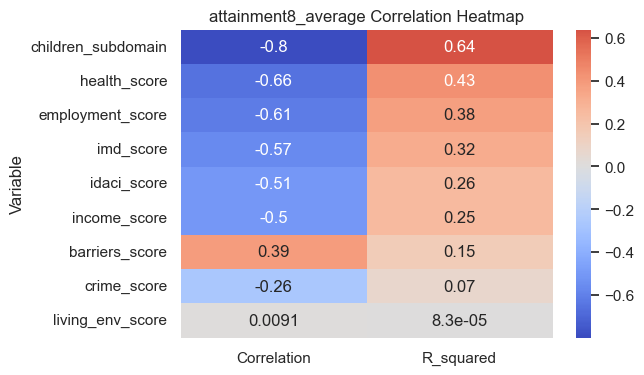

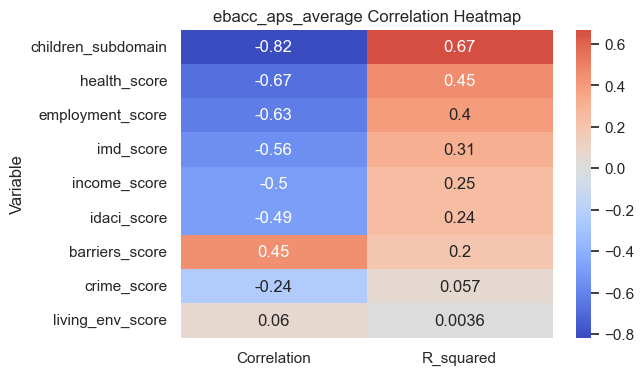

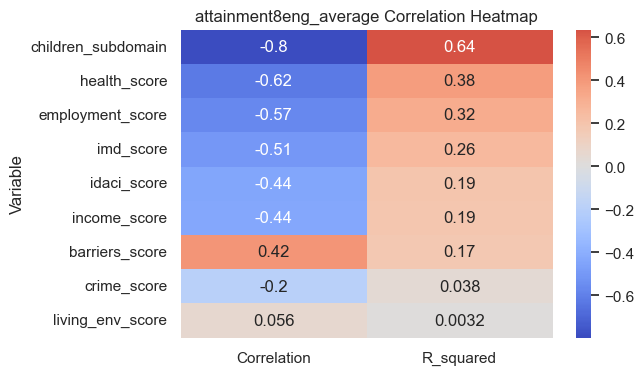

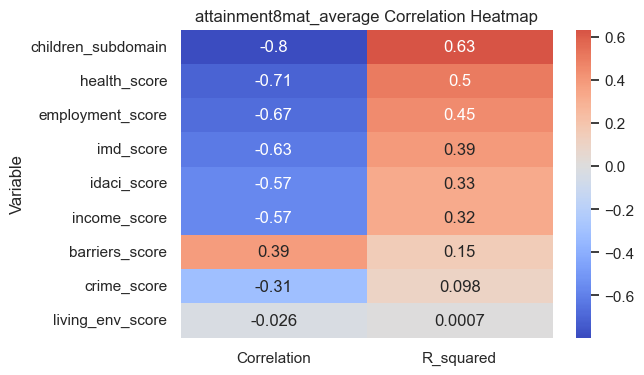

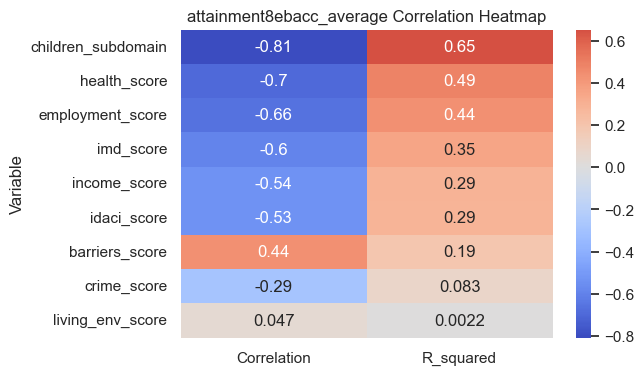

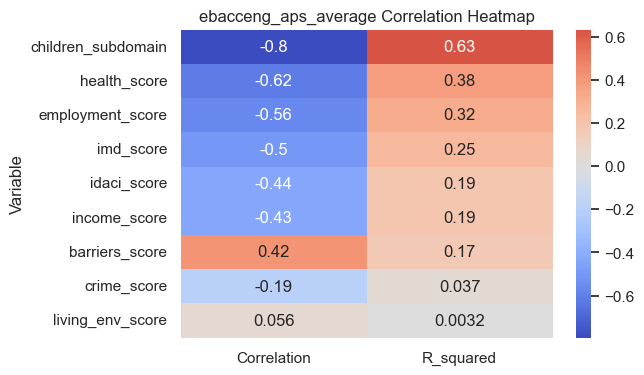

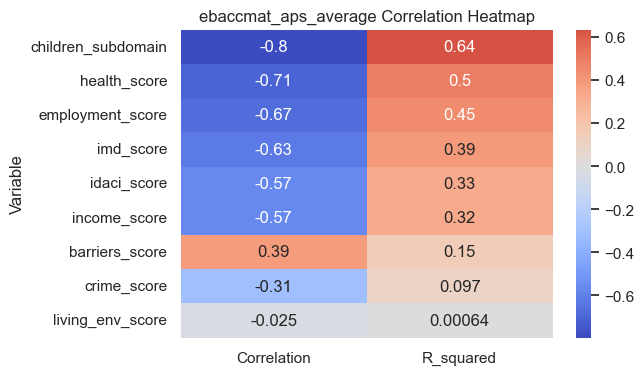

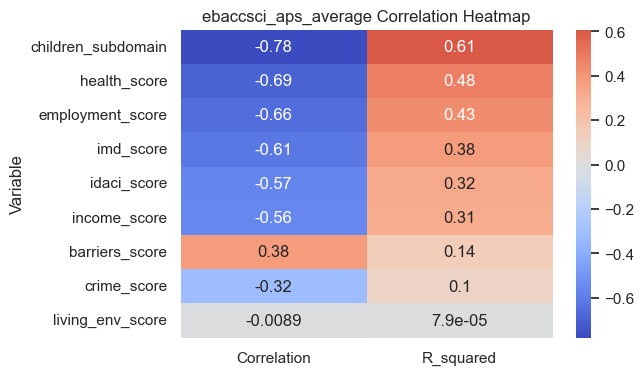

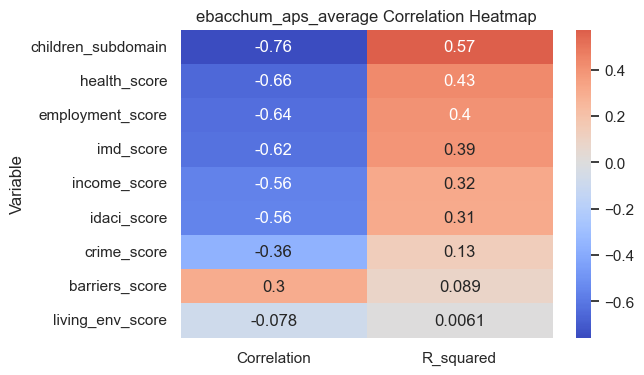

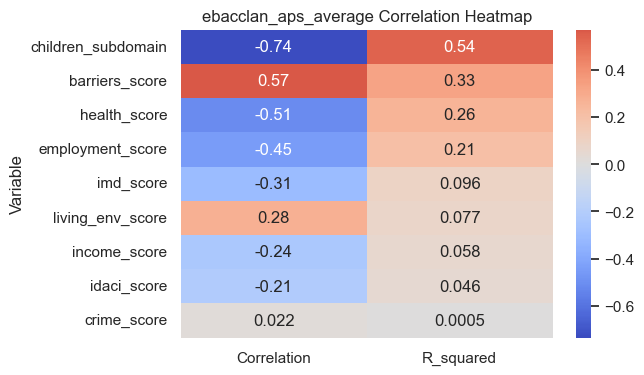

In [65]:
X_columns = [
    'imd_score',
    'income_score',
    'employment_score',
    'health_score',
    'crime_score',
    'barriers_score',
    'living_env_score',
    'idaci_score',
    'children_subdomain'
    ]

y_columns = ['attainment8_average',
             'ebacc_aps_average',
             'attainment8eng_average',
             'attainment8mat_average',
             'attainment8ebacc_average',
             'ebacceng_aps_average',
             'ebaccmat_aps_average',
             'ebaccsci_aps_average',
             'ebacchum_aps_average',
             'ebacclan_aps_average']

for y_col in y_columns:
    correlation_results = []

    for col in X_columns:
        r = df_examined[col].corr(df_examined[y_col])

        correlation_results.append({
            'Variable': col,
            'Correlation': r,
            'R_squared': r**2
        })

    correlation_results_df = pd.DataFrame(correlation_results)

    correlation_results_df = correlation_results_df.sort_values(
        'Correlation',
        key=abs,
        ascending=False
    )

    correlation_results_df = correlation_results_df.set_index('Variable')

    plt.figure(figsize=(6,4))
    sns.heatmap(
        correlation_results_df,
        annot=True,
        cmap='coolwarm',
        center=0
    )

    plt.title(f'{y_col} Correlation Heatmap')
    plt.show()

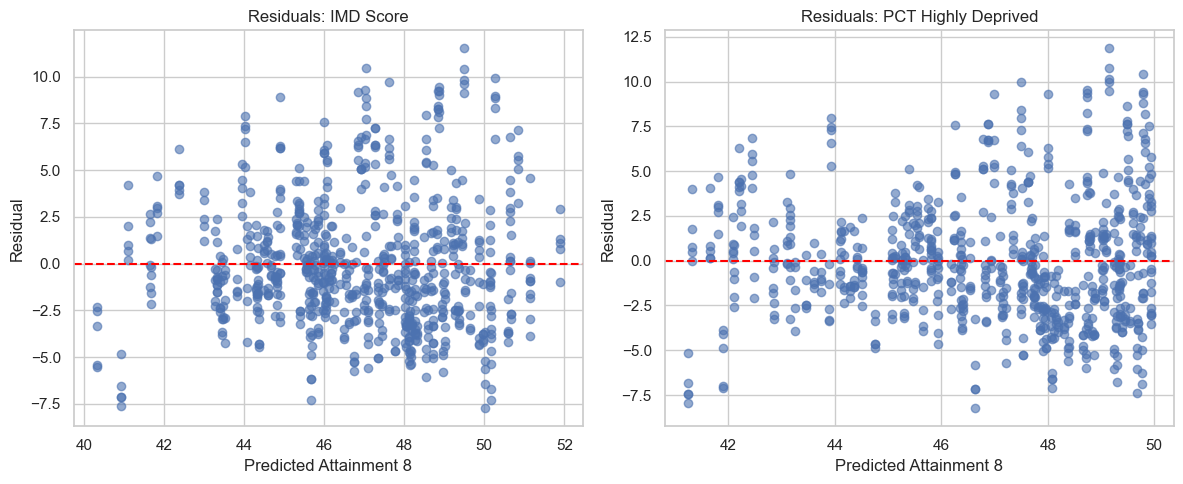

In [52]:
# Residuals
# Fit linear regression of attainment8 on imd_score
# Residuals are positive when a LA 'outperforms, negative when it 'underperforms'

def residuals(df, deprivation_col):
    """Calculate residual Attainment 8 scores from a linear deprivation model.

    Args:
        df (pd.DataFrame): DataFrame containing the deprivation score specified by ``deprivation_col`` and an
average attainment 8 score per LA (``attainment8_average``) column.
        deprivation_col (str): The name of the column in the dataframe df containing the deprivation score

    Returns:
        pd.DataFrame: A copy of ``df`` with two additional columns: 
        1. ``predicted_a8``: Predicted Attainment 8 score from fitted linear model.
        2. ``residual``: Difference between observed and predicted Attainment 8 scores.
    """
    df = df.copy()
    coeffs = np.polyfit(df[deprivation_col], df['attainment8_average'], 1)
    slope, intercept = coeffs
    df['predicted_a8'] = intercept + slope * df[deprivation_col]
    df['residual'] = df['attainment8_average'] - df['predicted_a8']
    return df

df_residuals_imd = residuals(df_examined, 'imd_score')
df_residuals_pct = residuals(df_examined, 'pct_highly_deprived')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_residuals_imd['predicted_a8'], df_residuals_imd['residual'], alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Attainment 8')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals: IMD Score')

axes[1].scatter(df_residuals_pct['predicted_a8'], df_residuals_pct['residual'], alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Attainment 8')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals: PCT Highly Deprived')

plt.tight_layout()
plt.show()

It is interesting to observe that, while the residuals appear random, they do not appear to be perfectly centred around 0 (the y-axis goes from -7.5 to +10.0 in both plots). This may be due to the collation of many years data here, including the COVID years of inflated teacher assessed grades, and it is plausible that the residuals would be centred around 0 when viewed per year. Equally, our assumption of independence is unlikely to acceptable - the deprivation level in a particular LA in a particular year will be not entirely independent of its deprivation level in other years, and a similar association may be seen in attainment.

Our RQ is interested in consistent high performing and consistent low performing LA's, so it is important to look per year and evaluate.

--- 201819 residual plots ---


/var/folders/hc/5z1l136x7b12q7qzw10d_3kw0000gn/T/ipykernel_1124/2157301641.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: residuals(g, deprivation_col))
/var/folders/hc/5z1l136x7b12q7qzw10d_3kw0000gn/T/ipykernel_1124/2157301641.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: residuals(g, deprivation_col))


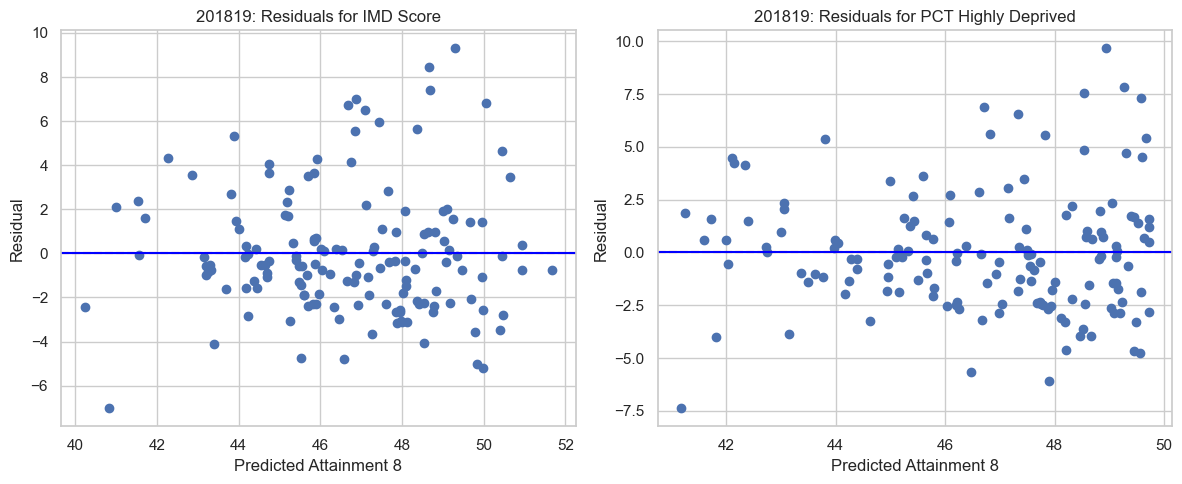

--- 202122 residual plots ---


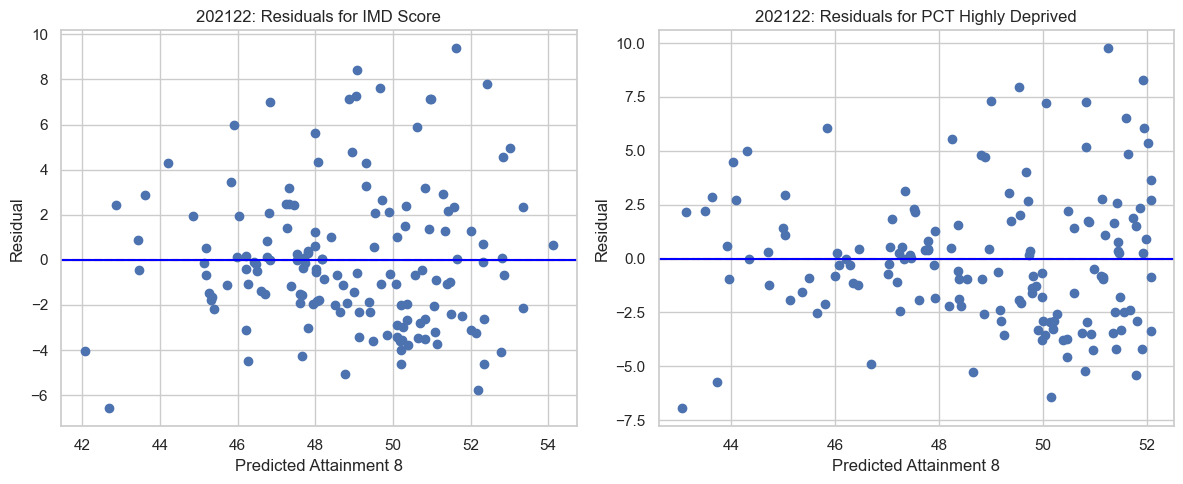

--- 202223 residual plots ---


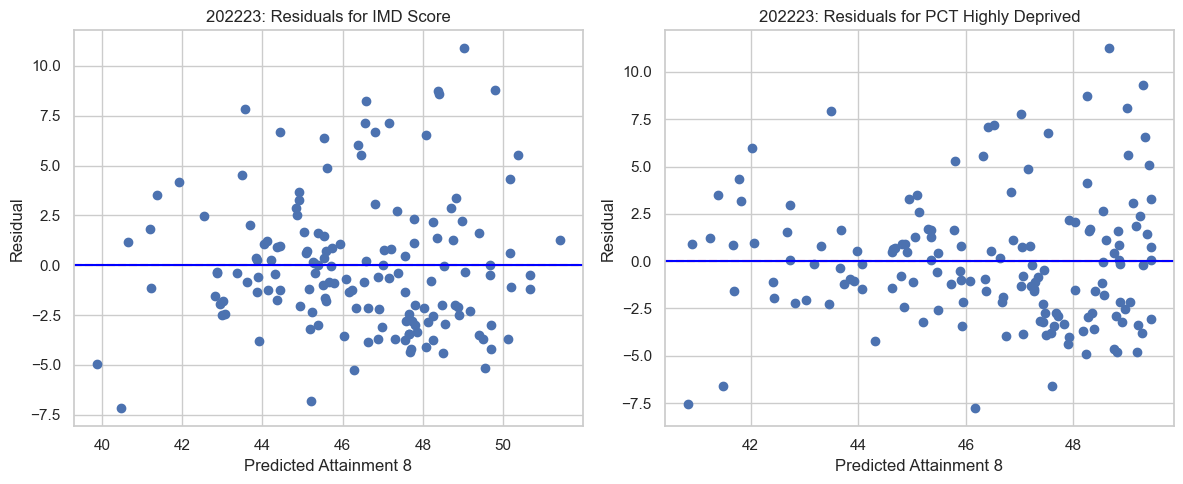

--- 202324 residual plots ---


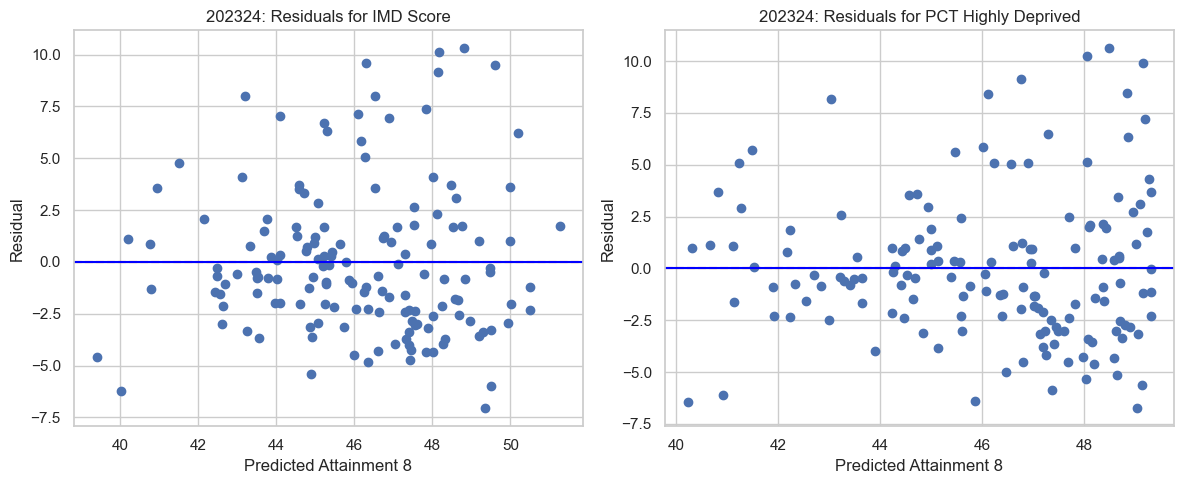

--- 202425 residual plots ---


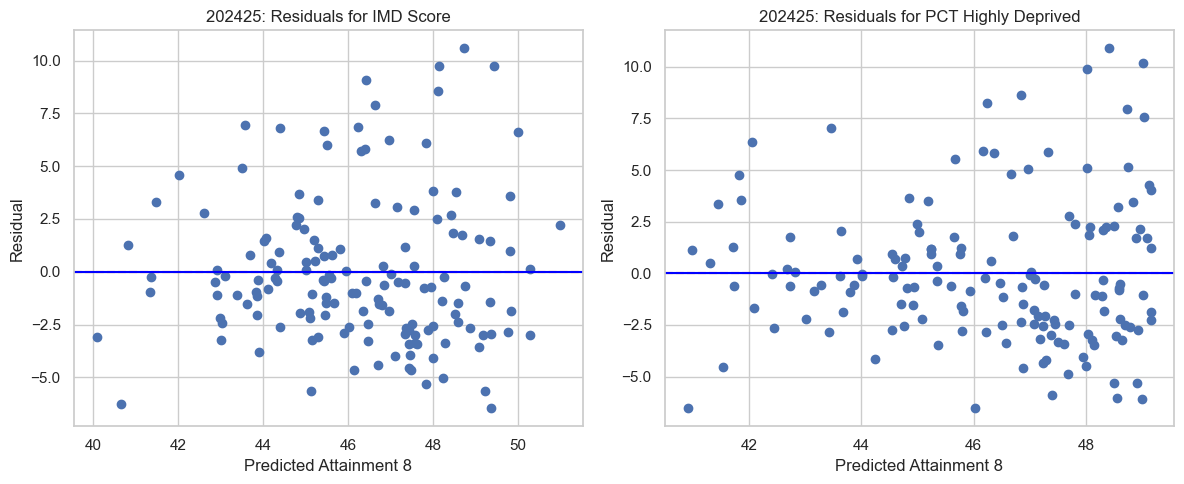

In [53]:
def residuals_per_year(df, deprivation_col):
    """Calculates residual Attainment 8 scores using a separate deprivation model
    for each year.

    Args:
        df (pd.DataFrame): DataFrame containing containing a ``year`` column, the deprivation score specified by ``deprivation_col`` and an
average attainment 8 score per LA (``attainment8_average``) column.
        deprivation_col (str): The name of the column in the dataframe df containing the deprivation score

    Returns:
        Returns:
        pd.DataFrame: A copy of ``df`` with two additional columns: 
        1. ``predicted_a8``: Predicted Attainment 8 score from year-specificfitted linear model.
        2. ``residual``: Difference between observed and predicted Attainment 8 scores for that year.
    """
    return (
    df.groupby('time_period', group_keys=False)
      .apply(lambda g: residuals(g, deprivation_col))
)

years = sorted(df_examined['time_period'].unique())

# Build residual datasets (by year)
df_residuals_imd = residuals_per_year(df_examined, 'imd_score')
df_residuals_pct = residuals_per_year(df_examined, 'pct_highly_deprived')

# Plot residuals for each year
for year in years:
    imd_year = df_residuals_imd[df_residuals_imd['time_period'] == year]
    pct_year = df_residuals_pct[df_residuals_pct['time_period'] == year]

    print(f"--- {year} residual plots ---")

    imd_mean = imd_year['residual'].mean()
    pct_mean = pct_year['residual'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(imd_year['predicted_a8'], imd_year['residual'])
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].axhline(imd_mean, color='blue', linestyle='-', label=f'IMD Mean: {imd_mean:.2f}')
    axes[0].set_xlabel('Predicted Attainment 8')
    axes[0].set_ylabel('Residual')
    axes[0].set_title(f"{year}: Residuals for IMD Score")

    axes[1].scatter(pct_year['predicted_a8'], pct_year['residual'])
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].axhline(pct_mean, color='blue', linestyle='-', label=f'PCT Mean: {pct_mean:.2f}')
    axes[1].set_xlabel('Predicted Attainment 8')
    axes[1].set_ylabel('Residual')
    axes[1].set_title(f"{year}: Residuals for PCT Highly Deprived")

    plt.tight_layout()
    plt.show()

It is interesting that despite the asymmetry of the y-axis ranges, in each case the mean looks on visual inspection to be at zero, as indicated by the blue line.


# Which LA's outperform or underperform?

We need to identify where the attainment 8 score is lower than or higher than, expected. That is, that their residuals are big. In order to allow for a larger cohort of overperformers and underperformers, this analysis looks at the mean residuals (over the timeframe) that are more than 1 standard deviation away from the mean in either direction.

In [54]:
# Calculate mean residual per LA across all examined years
la_mean_residuals = (
    df_residuals_imd
    .groupby('la_name')['residual']
    .mean()
    .reset_index()
    .rename(columns={'residual': 'mean_residual'})
)

# Merge back onto deduped dataframe
no_dup_residuals = df_residuals_imd.drop_duplicates(subset='la_name').copy()
no_dup_residuals = no_dup_residuals.merge(la_mean_residuals, on='la_name', how='left')

# Standard deviation threshold as IQR showed inconsistent outliers - lots of overperformers and no underperformers!
mean = no_dup_residuals['mean_residual'].mean()
std = no_dup_residuals['mean_residual'].std()

upper_fence = mean + std
lower_fence = mean - std

print(f"Mean: {mean:.2f}")
print(f"Std: {std:.2f}")
print(f"Lower fence: {lower_fence:.2f}, Upper fence: {upper_fence:.2f}")

no_dup_residuals['performance_group'] = 'Average'
no_dup_residuals.loc[no_dup_residuals['mean_residual'] >= upper_fence, 'performance_group'] = 'Outperformer'
no_dup_residuals.loc[no_dup_residuals['mean_residual'] <= lower_fence, 'performance_group'] = 'Underperformer'


print("\nPerformance group counts:")
print(no_dup_residuals['performance_group'].value_counts())

print("\n--- Outperformers ---")
print(no_dup_residuals[no_dup_residuals['performance_group'] == 'Outperformer']
      [['la_name', 'mean_residual']]
      .sort_values('mean_residual', ascending=False))

print("\n--- Underperformers ---")
print(no_dup_residuals[no_dup_residuals['performance_group'] == 'Underperformer']
      [['la_name', 'mean_residual']]
      .sort_values('mean_residual'))

Mean: -0.04
Std: 3.21
Lower fence: -3.25, Upper fence: 3.17

Performance group counts:
performance_group
Average           114
Underperformer     20
Outperformer       19
Name: count, dtype: int64

--- Outperformers ---
                    la_name  mean_residual
125                  Sutton      10.088404
70                 Trafford       8.608179
117    Kingston upon Thames       8.539861
109  Hammersmith and Fulham       8.471858
99                   Barnet       8.405994
108                 Hackney       6.817075
129             Westminster       6.782189
36                   Slough       6.776863
116  Kensington and Chelsea       6.672168
121                  Newham       6.307154
122               Redbridge       6.297189
30          Southend-on-Sea       6.162683
124               Southwark       5.796236
123    Richmond upon Thames       5.362688
105                  Ealing       5.201493
101                   Brent       5.161644
85               Birmingham       4.431530
55    

As can be seen above, there are 20 underperforming LA's and 19 overperformers. This is illustrated in the figure below.

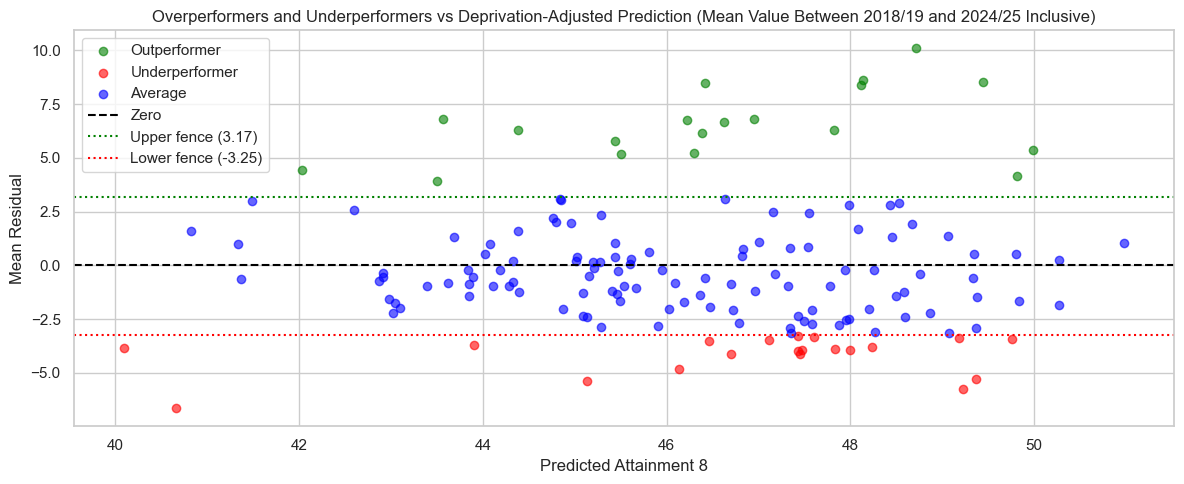

In [55]:
colour_map = {'Outperformer': 'green', 'Underperformer': 'red', 'Average': 'blue'}

fig, ax = plt.subplots(figsize=(12, 5))

for group, colour in colour_map.items():
    subset = no_dup_residuals[no_dup_residuals['performance_group'] == group]
    ax.scatter(subset['predicted_a8'], subset['mean_residual'],
               color=colour, alpha=0.6, label=group)

ax.axhline(0, color='black', linestyle='--', label='Zero')
ax.axhline(upper_fence, color='green', linestyle=':', label=f'Upper fence ({upper_fence:.2f})')
ax.axhline(lower_fence, color='red', linestyle=':', label=f'Lower fence ({lower_fence:.2f})')
ax.set_xlabel('Predicted Attainment 8')
ax.set_ylabel('Mean Residual')
ax.set_title('Overperformers and Underperformers vs Deprivation-Adjusted Prediction (Mean Value Between 2018/19 and 2024/25 Inclusive)')
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation of the Overperfoming Local Authorities

The top 8 overperforming LA's are all London boroughs. The majority of the rest of the 19 overperformers are either also London boroughs, or very urban/commuter areas. This report is therefore consistent with the well documented "London Effect" (see, for example, Ross et. al (2020) available here: https://www.gov.uk/government/publications/examining-the-london-advantage-in-attainment-evidence-from-lsype)

## Interpretation of Underperforming Local Authorities

Knowsley (-6.65) is most extreme underperformer by a margin, which was also highlighted in our exploratory data analysis. The rest of the underperformers are predominantly coastal, rural, or post-industrial areas. Again, this is consistent with trends reported in the wider media, known as the "grass ceiling".

It is important to highlight that both Cumberland and North Northamptonshire appear in the list of underperforming Local Authorities. However, as has been previously discussed, these are authorities that have had their boundaries redefined, and renamed. Therefore, this classification of these two authorities as underperforming is less reliable.

# Research Question 7: Which Local Authorities consistently outperform their predicted Attainment 8 score given their deprivation level, and are there identifiable patterns among these consistent outperformers?

This question aims to support policy makers in identifying, at a LA level, what features or factors might be associated with academic performance when compared with deprivation levels.

The mean overperformers have already been flagged above. As has been noted, there is the "London Effect" and the rural/coastal effect seen in overperformers and underperformers respectively. Therefore, three actions are taken to address this question:

1. Categorise LAs as London and not-London in order to explicitly investigate the "London Effect".
2. Review the residuals for LAs (both underperforming and overperforming) for each year, in order to interrogate the consistency of the effect.
3. Investigate the sub-domain scores of overperformers versus underperformers to explore whether any particular sub-domain contributes disproportionately to the residuals.

## Investigating the "London Effect"

In [56]:
london_boroughs = [
    'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley',
    'Camden', 'City of London', 'Croydon', 'Ealing', 'Enfield',
    'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Haringey',
    'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington',
    'Kensington and Chelsea', 'Kingston upon Thames', 'Lambeth',
    'Lewisham', 'Merton', 'Newham', 'Redbridge', 'Richmond upon Thames',
    'Southwark', 'Sutton', 'Tower Hamlets', 'Waltham Forest', 'Wandsworth',
    'Westminster'
]

no_dup_residuals['is_london'] = no_dup_residuals['la_name'].isin(london_boroughs)

london_summary = (
    no_dup_residuals
    .groupby(['performance_group', 'is_london'])
    .size()
    .reset_index(name='count')
)

print(london_summary)

  performance_group  is_london  count
0           Average      False     96
1           Average       True     18
2      Outperformer      False      5
3      Outperformer       True     14
4    Underperformer      False     20


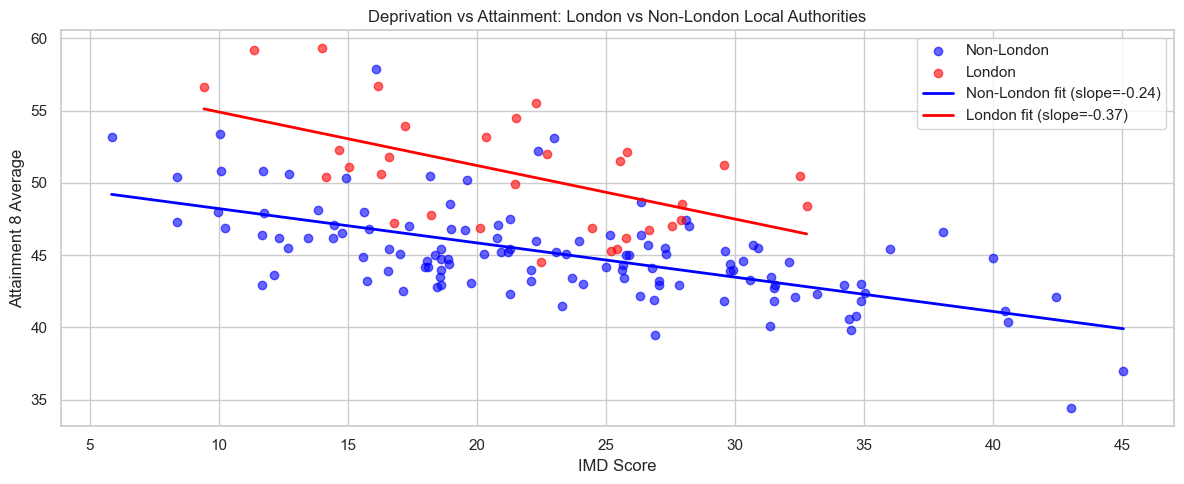

In [57]:
london_data = no_dup_residuals[no_dup_residuals['is_london']]
non_london_data = no_dup_residuals[~no_dup_residuals['is_london']]


london_coeffs = np.polyfit(london_data['imd_score'], london_data['attainment8_average'], 1)
non_london_coeffs = np.polyfit(non_london_data['imd_score'], non_london_data['attainment8_average'], 1)

london_slope, london_intercept = london_coeffs
non_london_slope, non_london_intercept = non_london_coeffs

fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(non_london_data['imd_score'], non_london_data['attainment8_average'],
           color='blue', alpha=0.6, label='Non-London')
ax.scatter(london_data['imd_score'], london_data['attainment8_average'],
           color='red', alpha=0.6, label='London')

x_non_london = np.linspace(non_london_data['imd_score'].min(), non_london_data['imd_score'].max(), 100)
x_london = np.linspace(london_data['imd_score'].min(), london_data['imd_score'].max(), 100)

ax.plot(x_non_london, non_london_intercept + non_london_slope * x_non_london,
        color='blue', linewidth=2, label=f'Non-London fit (slope={non_london_slope:.2f})')
ax.plot(x_london, london_intercept + london_slope * x_london,
        color='red', linewidth=2, label=f'London fit (slope={london_slope:.2f})')

ax.set_xlabel('IMD Score')
ax.set_ylabel('Attainment 8 Average')
ax.set_title('Deprivation vs Attainment: London vs Non-London Local Authorities')
ax.legend()
plt.tight_layout()
plt.show()

The graph above highlights some interesting findings:

1. The London graph (red) shows that within the range of IMD scores in London, London boroughs show higher Attainment 8 average at every IMD score.
2. The slope of the London graph is steeper. At higher levels of deprivation, the gap between London boroughs and other LAs with similar levels of deprevation decreases. This would suggest that the idea of the "London effect" as being a buffer against the effects of deprivation is not as exaggerated as presented in the media. What this graph indicates is that London's advantage is concentrated in its less deprived (wealthier) LA's, not evenly spread across all of them. 

However, as can be seen clearly in the graph, London's LA's are limited in IMD score from betwen approximately 9 to approximately 33. As London's data doesn't extend into the highest deprivation range. Thus, while this pattern is suggestive and merits further consideration, it cannot be taken as conclusive.

### Non-London Outperformers

In [58]:
non_london_overperformers = no_dup_residuals[
    (no_dup_residuals['performance_group'] == 'Outperformer') &
    (~no_dup_residuals['is_london'])
]

print(non_london_overperformers[['la_name', 'mean_residual', 'imd_score']]
      .sort_values('mean_residual', ascending=False))

            la_name  mean_residual  imd_score
70         Trafford       8.608179  16.087826
36           Slough       6.776863  22.965258
30  Southend-on-Sea       6.162683  22.374771
85       Birmingham       4.431530  38.067008
55  Buckinghamshire       4.147641  10.051630


In [59]:
non_london_overperformers_list = ['Trafford', 'Slough', 'Southend-on-Sea', 'Birmingham', 'Buckinghamshire']

profile = no_dup_residuals[no_dup_residuals['la_name'].isin(non_london_overperformers_list)]
print(profile[['la_name', 'mean_residual', 'imd_score', 'income_score', 
               'employment_score', 'barriers_score', 'pupil_count']])

            la_name  mean_residual  imd_score  income_score  employment_score  \
30  Southend-on-Sea       6.162683  22.374771      0.144341          0.108810   
36           Slough       6.776863  22.965258      0.126031          0.080243   
55  Buckinghamshire       4.147641  10.051630      0.066295          0.051719   
70         Trafford       8.608179  16.087826      0.106962          0.088359   
85       Birmingham       4.431530  38.067008      0.221773          0.156527   

    barriers_score  pupil_count  
30       17.644502         2446  
36       36.279968         2476  
55       24.397041         6511  
70       13.793855         3429  
85       31.627583        14971  


Beyond London, the overperformers do not seem to share any obvious scores or traits as measured within our datasets. Each measured deprivation score varies hugely, and not consistently, while the pupil numbers are wildly disparate too. Even geographically, we have Birmingham as a large urban centre in the Midlands, while several of the remaining overperformers are small or medium LA's in the South-East (generally in the commmuter belt).


## Is the relationship between IMD Score and Average Attainment 8 Score consistent over time for each LA?

First, we will explore the overperformers and underperformers. Are these gaps narrowing or widening, and is this too, an area where the "London Effect" is relevant?

A consistency table comparing each year to the mean of the LA residual will give insight into whether there are any individual trends.

In [60]:
overperformers = no_dup_residuals[no_dup_residuals['performance_group'] == 'Outperformer']['la_name']
underperformers = no_dup_residuals[no_dup_residuals['performance_group'] == 'Underperformer']['la_name']

flagged_las = pd.concat([overperformers, underperformers])

consistency_table = (
    df_residuals_imd[df_residuals_imd['la_name'].isin(flagged_las)]
    [['la_name', 'time_period', 'residual']]
    .pivot(index='la_name', columns='time_period', values='residual')
    .round(2)
)

consistency_table['positive_years'] = (consistency_table.iloc[:, :5] > 0).sum(axis=1)
consistency_table['negative_years'] = (consistency_table.iloc[:, :5] < 0).sum(axis=1)

print(consistency_table)

time_period              201819  202122  202223  202324  202425  \
la_name                                                           
Barking and Dagenham       2.69    3.46    4.51    4.08    4.90   
Barnet                     8.43    7.15    8.72    9.15    8.58   
Birmingham                 4.33    4.30    4.17    4.79    4.57   
Blackpool                 -2.43   -4.06   -4.98   -4.60   -3.09   
Bracknell Forest          -3.49   -4.07   -3.72   -2.94   -2.86   
Brent                      4.28    4.34    4.89    6.30    6.00   
Buckinghamshire            4.65    4.57    4.32    3.61    3.59   
Central Bedfordshire      -5.03   -5.79   -5.16   -7.06   -5.63   
Cumberland                  NaN     NaN   -3.68   -4.30   -4.40   
Dorset                    -2.39   -3.18   -4.41   -3.97   -5.03   
Ealing                     4.15    4.77    5.55    5.84    5.71   
East Sussex               -2.31   -3.34   -3.72   -3.95   -4.01   
Hackney                    5.31    5.99    7.84    8.01    6.9

In [61]:
consistency_table['trend'] = consistency_table[202425] - consistency_table[201819]

print(consistency_table[[201819, 202425, 'trend']].sort_values('trend', ascending=False))


time_period              201819  202425  trend
la_name                                       
Richmond upon Thames       3.47    6.62   3.15
Southwark                  3.65    6.67   3.02
Kingston upon Thames       6.84    9.76   2.92
Newham                     4.05    6.81   2.76
Trafford                   7.41    9.77   2.36
Barking and Dagenham       2.69    4.90   2.21
Hammersmith and Fulham     7.02    9.08   2.06
Brent                      4.28    6.00   1.72
Hackney                    5.31    6.93   1.62
Ealing                     4.15    5.71   1.56
Kensington and Chelsea     6.50    7.88   1.38
Sutton                     9.30   10.58   1.28
Knowsley                  -7.03   -6.26   0.77
Bracknell Forest          -3.49   -2.86   0.63
Leicestershire            -3.58   -2.98   0.60
Redbridge                  5.64    6.08   0.44
Westminster                5.96    6.25   0.29
Southend-on-Sea            5.55    5.81   0.26
Birmingham                 4.33    4.57   0.24
Slough       

A brief view comparing 2018/19 with 2024/25 gives a blunt view of whether the trend for each LA is widening or closing. The top of the table is London dominated again (with the interesting exception of Trafford), while the bottom of the table, indicating worsening relationship between IMD score and average Attainment 8 score, is predominantly rural and/or costal LAs.

It therefore appears that London's overperformance against deprivation predictions is not only present but is actually accelerating, while more rural or costal LAs show a worsening performance against deprivation predictions. This divergence suggests the structural advantage benefiting London LAs is strengthening over the period studied, rather than reflecting a one-off historical pattern. Future studies into the efficacy of non-academic interventions to increase attainment would therefore merit investigation into the structural, cultural and other areas of difference between London and the rest of England.

## Do any sub-domains contribute disproprortionately to the residuals of average Attainment 8 score versus IMD score?

In [62]:
sub_domains = [
    'income_score', 'employment_score', 'health_score',
    'crime_score', 'barriers_score', 'living_env_score'
]

group_comparison = (
    no_dup_residuals[no_dup_residuals['performance_group'] != 'Average']
    .groupby('performance_group')[sub_domains]
    .mean()
    .round(2)
)

print(group_comparison)

                   income_score  employment_score  health_score  crime_score  \
performance_group                                                              
Outperformer               0.13              0.09         -0.38         0.20   
Underperformer             0.12              0.10         -0.02        -0.13   

                   barriers_score  living_env_score  
performance_group                                    
Outperformer                30.83             28.69  
Underperformer              20.74             20.99  


There are several interesting differences between overperformers and underperformers as highlighted in the above table.

Firstly, and possibly most intuitively, overperformers face less health deprivation when compared to underperformers. So it is plausible, and should be investigated, whether health interventions support educational outcomes as well as improved medical outcomes. However, this is a huge area, and the metrics of measuring and reducing health deprivation are complex. This table only compares overperformers and underperformers, and does not include the 'average' group of LA's. The box plots (below) confirm that this relationship is not monotonic: the Average group shows higher health deprivation than both Outperformers and Underperformers, which suggests that this may not be a clear distinguishing driver of educational outcomes.

Overperformers have higher barriers_score (30.83 vs 20.74) and higher living_env_score (28.69 vs 20.99) than underperformers. This may track back to the "London Effect", or at least an urban effect, as it is likely that urban LAs face greater housing pressures and living environment pressures than less densely populated areas. It is therefore not suggested that an intervention in this area would increase educational outcomes!

A similar relationship is seen with crime: underperforming LAs see lower crime deprivation, while outperforming LAs see higher crime deprivation. Again, this may be related to the urban/rural split rather than any positive assocations between crime and educational attainment.

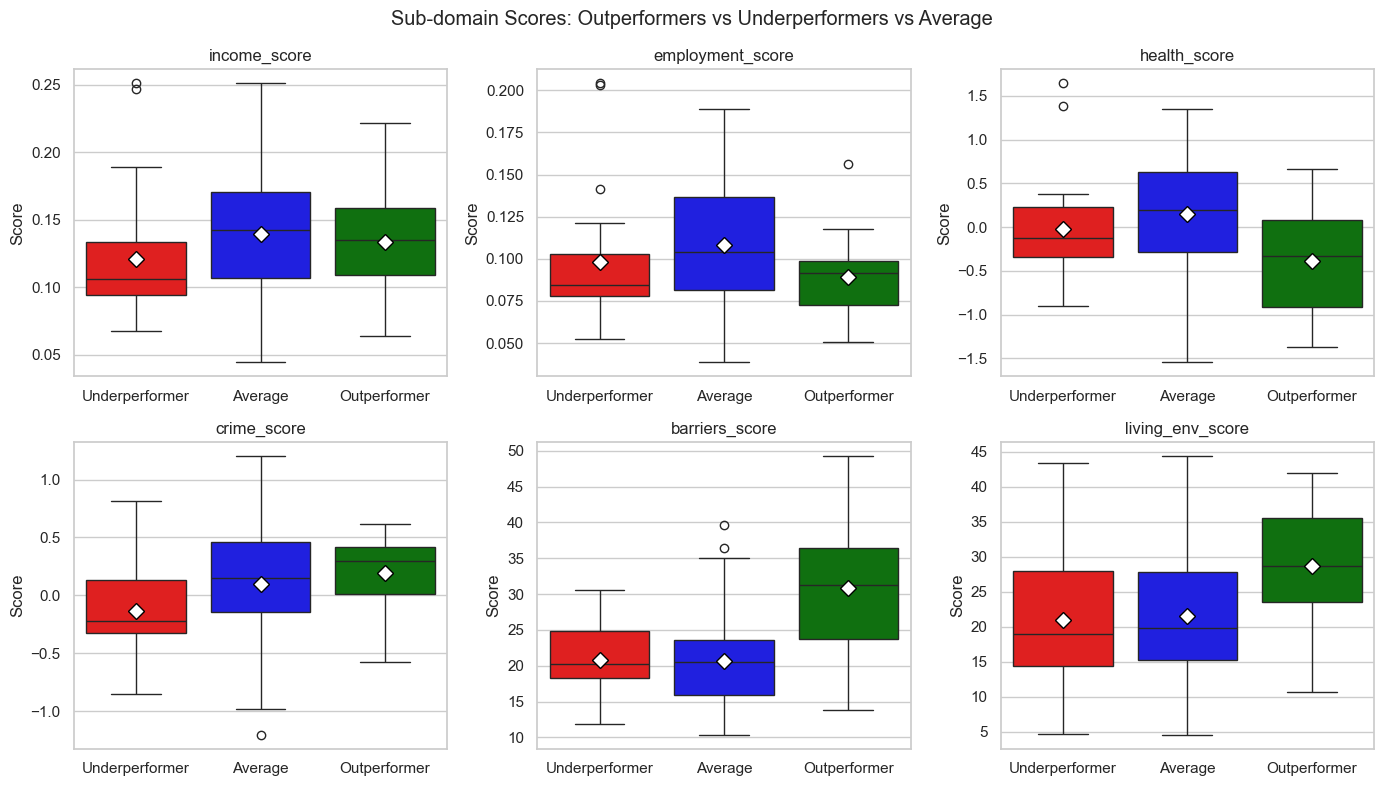

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

all_groups = no_dup_residuals.copy()

for i, col in enumerate(sub_domains):
    sns.boxplot(
        data=all_groups,
        x='performance_group',
        y=col,
        hue='performance_group',
        order=['Underperformer', 'Average', 'Outperformer'],
        palette={'Underperformer': 'red', 'Average': 'blue', 'Outperformer': 'green'},
        legend=False,
        showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': 'white', 
                   'markeredgecolor': 'black', 'markersize': 8},
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Score')

plt.suptitle('Sub-domain Scores: Outperformers vs Underperformers vs Average')
plt.tight_layout()
plt.show()

In [64]:
print(no_dup_residuals.groupby(['is_london', 'performance_group'])['crime_score'].mean())

is_london  performance_group
False      Average              0.065274
           Outperformer         0.065252
           Underperformer      -0.131151
True       Average              0.274661
           Outperformer         0.241340
Name: crime_score, dtype: float64


None of the six sub-domains shows a relationship with average Attainment 8 score that survives stratifying by London membership. There is no monotonically (consistently) increasing or decreasing between underperformer to average to overperformer.